![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [152]:
import warnings
warnings.filterwarnings('ignore')

In [153]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz, DecisionTreeClassifier
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score, precision_score, accuracy_score
from sklearn import metrics

In [154]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


In [155]:
display(Markdown(f"""### Datos iniciales:
                 \n Los datos cargados originalmente se componen de {bikes.shape[0]} filas, cada una representa una observación y {bikes.shape[1]} columnas, cada columna representa una variable."""))

#### Análisis Valores Nulos\n
display(Markdown(f""" ### Análisis Valores Nulos:
    \n El dataset resultante tiene {bikes.isnull().sum().sum()} valores nulos."""))

### Datos iniciales:
                 
 Los datos cargados originalmente se componen de 10886 filas, cada una representa una observación y 12 columnas, cada columna representa una variable.

 ### Análisis Valores Nulos:
    
 El dataset resultante tiene 0 valores nulos.

### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [156]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [157]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [158]:
display(Markdown(f"""Para hacer un análisis más completo de las variables ***season*** y ***hour***, se busca mostrar el comportamiento de la demanda de bicicletas haciendo uso del metodo .describe()
                 para ver algunas métricas como; *media, mediana, conteo, desviación estandar, mínimos, máximosy percentiles). Adicionalemnte, se incorporan dos metricas, ***IQR*** el rango intercuar
                 tilico y el limite superior, pudiendo ver la variablididad de los datos y definiendo el limite que permitirá identifcar outliers."""
))

def analisis_descriptivo(df, columna):
    metricas = df.groupby(columna)['total'].describe()
    
    #Rango intercuartilico
    metricas['IQR'] = metricas['75%'] - metricas['25%']
    
    #Limite superiro para poder detectar outliers
    metricas['Lim_Sup'] = metricas['75%'] + 1.5 * metricas['IQR']

    display(Markdown(f"""#### Resumen descriptivo de la variable {columna}"""))
    display(metricas)

analisis_descriptivo(bikes, 'season')
display(Markdown(f"""Para la variable ***Season***, se pudo observar que hay dos estaciones (2 y 3) que concentran la mayoría de la demanda con valores promedio por encima de 200 bicicletas rentadas, 
                 sin embargo, la estación 4 a pesar de tener un promedio menor, es la segunda estación con mayor número de bicicletas rentadas, teniendo un 2734 registros y un máximo de bicicletas de 948.
                 
                 \n Adicional, mediante el IQR se puede ver que los mayores valores tamién se ubican en las estaciones 2 y 3, siendo el mayor valor en la estación 3 (279), para lo cual se puede decir 
                 que durante estos meses existe más variabilidad en la demanda. Caso contrario a la estación 1, en donde se tiene un valor de 140, po lo cual se puede decir que la demanda es más estable.
                 
                 \n Finalmente, se puede decir que la demana de bicicletas presenta gran variabilidad durante el año, especialmente en las estaciones 2 y 3, dados los valores observados; ademá, se 
                 evidencia la presencia de outiers en todas las estaciones, dado que para todos los casos el valor máximo supera el limite superior calculado por medio de los cuartiles."""))

analisis_descriptivo(bikes, 'hour')
display(Markdown(f"""Para la variable ***Hour***, se pudo observar que los picos de demanda de bicicletas están alineados con la jornada laboral ordinaria, teniendo dos puntos en el día en donde el 
                 promedio es más alto, siendo estas las 8 y entre las 17 y 18, presentando valores de 362 y 468 a 430 respectivamente. 
                 
                 \n Por otr lado, se ve que la cantidad de registrso es ligeramente menor para algunas horas de la madrugada, pero que la cantidad es constante para la mayoria de horas del dataset.
                 
                 \n Observando los valores de IQR tnemos que la hora con más variabilidad de demanada de bicicletas durante el día corresponde a ls 8 horas, con un valor de 430, seguido de los valores
                 del segundo 'pico del día' (17 a 18) con valores de 331 y 323. Por el contrario, si vemos horas cercanas a la madrugada, vemos que el IQR baja hasta 6 para la hora 4, en donde podemos
                 decir que además de tener una demanda baja, esta es estable a esta hora.
                 
                 \n En cuanto a los outliers, se puede ver que casi todas las horasa cuentan con valores atipicos, a excepción de las horas pico del día, en donde el valor máximo no supera al limite
                 superior calculado. Lo anterior sugiere que cuando la demanda es alta, esta se mantiene 'controlada' dentro de los rangos calculados mediante los percentiles, pero que por el contrario, 
                 en horas en donde la demanda es baja, cualquier cambio puede verse como una anomalia al generar un impacto grande dentro de los datos."""))

Para hacer un análisis más completo de las variables ***season*** y ***hour***, se busca mostrar el comportamiento de la demanda de bicicletas haciendo uso del metodo .describe()
                 para ver algunas métricas como; *media, mediana, conteo, desviación estandar, mínimos, máximosy percentiles). Adicionalemnte, se incorporan dos metricas, ***IQR*** el rango intercuar
                 tilico y el limite superior, pudiendo ver la variablididad de los datos y definiendo el limite que permitirá identifcar outliers.

#### Resumen descriptivo de la variable season

,count,mean,std,min,25%,50%,75%,max,IQR,Lim_Sup
season,,,,,,,,,,
1,2686.0,116.343261,125.273974,1.0,24.0,78.0,164.0,801.0,140.0,374.0
2,2733.0,215.251372,192.007843,1.0,49.0,172.0,321.0,873.0,272.0,729.0
3,2733.0,234.417124,197.151001,1.0,68.0,195.0,347.0,977.0,279.0,765.5
4,2734.0,198.988296,177.622409,1.0,51.0,161.0,294.0,948.0,243.0,658.5


Para la variable ***Season***, se pudo observar que hay dos estaciones (2 y 3) que concentran la mayoría de la demanda con valores promedio por encima de 200 bicicletas rentadas, 
                 sin embargo, la estación 4 a pesar de tener un promedio menor, es la segunda estación con mayor número de bicicletas rentadas, teniendo un 2734 registros y un máximo de bicicletas de 948.

                 
 Adicional, mediante el IQR se puede ver que los mayores valores tamién se ubican en las estaciones 2 y 3, siendo el mayor valor en la estación 3 (279), para lo cual se puede decir 
                 que durante estos meses existe más variabilidad en la demanda. Caso contrario a la estación 1, en donde se tiene un valor de 140, po lo cual se puede decir que la demanda es más estable.

                 
 Finalmente, se puede decir que la demana de bicicletas presenta gran variabilidad durante el año, especialmente en las estaciones 2 y 3, dados los valores observados; ademá, se 
                 evidencia la presencia de outiers en todas las estaciones, dado que para todos los casos el valor máximo supera el limite superior calculado por medio de los cuartiles.

#### Resumen descriptivo de la variable hour

,count,mean,std,min,25%,50%,75%,max,IQR,Lim_Sup
hour,,,,,,,,,,
0,455.0,55.138462,43.620012,2.0,24.00,41.0,74.50,283.0,50.50,150.250
1,454.0,33.859031,34.112105,1.0,11.00,19.0,46.00,168.0,35.00,98.500
2,448.0,22.899554,26.110267,1.0,5.00,11.0,32.00,119.0,27.00,72.500
3,433.0,11.757506,12.666442,1.0,3.00,6.0,15.00,66.0,12.00,33.000
4,442.0,6.407240,4.217633,1.0,3.00,6.0,9.00,28.0,6.00,18.000
5,452.0,19.767699,12.784293,1.0,8.00,19.0,29.00,57.0,21.00,60.500
6,455.0,76.259341,54.745333,1.0,24.50,75.0,118.00,213.0,93.50,258.250
7,455.0,213.116484,159.207044,1.0,63.00,208.0,334.00,596.0,271.00,740.500
8,455.0,362.769231,231.723065,8.0,133.50,392.0,563.50,839.0,430.00,1208.500


Para la variable ***Hour***, se pudo observar que los picos de demanda de bicicletas están alineados con la jornada laboral ordinaria, teniendo dos puntos en el día en donde el 
                 promedio es más alto, siendo estas las 8 y entre las 17 y 18, presentando valores de 362 y 468 a 430 respectivamente. 

                 
 Por otr lado, se ve que la cantidad de registrso es ligeramente menor para algunas horas de la madrugada, pero que la cantidad es constante para la mayoria de horas del dataset.

                 
 Observando los valores de IQR tnemos que la hora con más variabilidad de demanada de bicicletas durante el día corresponde a ls 8 horas, con un valor de 430, seguido de los valores
                 del segundo 'pico del día' (17 a 18) con valores de 331 y 323. Por el contrario, si vemos horas cercanas a la madrugada, vemos que el IQR baja hasta 6 para la hora 4, en donde podemos
                 decir que además de tener una demanda baja, esta es estable a esta hora.

                 
 En cuanto a los outliers, se puede ver que casi todas las horasa cuentan con valores atipicos, a excepción de las horas pico del día, en donde el valor máximo no supera al limite
                 superior calculado. Lo anterior sugiere que cuando la demanda es alta, esta se mantiene 'controlada' dentro de los rangos calculados mediante los percentiles, pero que por el contrario, 
                 en horas en donde la demanda es baja, cualquier cambio puede verse como una anomalia al generar un impacto grande dentro de los datos.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

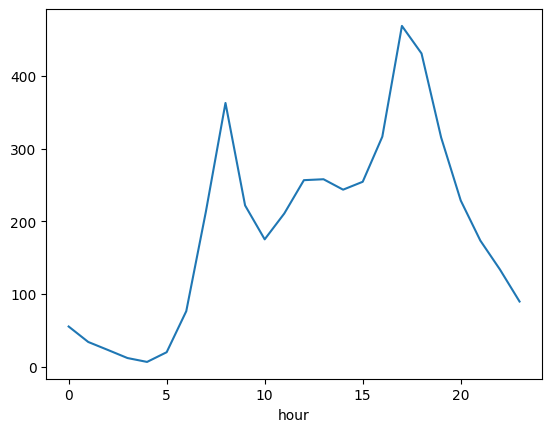

In [159]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

Después de replicar el análisis del promedio de las bicicletas rentadas durante las 4 estaciones del año y aplicarlo unicamente para la estación 1 (invierno), se puede observar 
                 que el comportamiento de la demanda es el mismo, es decir, la gráfica conserva el mismo patrón (dos picos durante el día; el primero a las 8 horas y el segundo entre las 17 y 18 horas), 
                 pero teniendo una escala distinta.

                 
 Como se mencionó anteriormente en el análisis descriptivo, la estación 1 tiene los promedios más bajo, lo cual se ve representado en la gráfica al esta desplazarse hacia abajo,
                 pudiendo verse que sus valores máximos cambian de ser cercanos a 400 (para el promedio por hora de todas las estaciones) a ser de poco mas de 250. Lo cual indica que al ser invierno, 
                 las personas sulene requerir este servicio en menor medida, dadas las condiciones climaticas y demás factores presentes en estos meses.

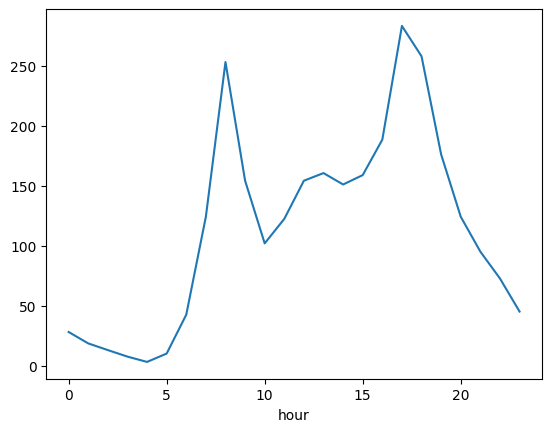

In [160]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 
bikes[bikes['season']==1].groupby('hour').total.mean().plot()
display(Markdown(f"""Después de replicar el análisis del promedio de las bicicletas rentadas durante las 4 estaciones del año y aplicarlo unicamente para la estación 1 (invierno), se puede observar 
                 que el comportamiento de la demanda es el mismo, es decir, la gráfica conserva el mismo patrón (dos picos durante el día; el primero a las 8 horas y el segundo entre las 17 y 18 horas), 
                 pero teniendo una escala distinta.
                 
                 \n Como se mencionó anteriormente en el análisis descriptivo, la estación 1 tiene los promedios más bajo, lo cual se ve representado en la gráfica al esta desplazarse hacia abajo,
                 pudiendo verse que sus valores máximos cambian de ser cercanos a 400 (para el promedio por hora de todas las estaciones) a ser de poco mas de 250. Lo cual indica que al ser invierno, 
                 las personas sulene requerir este servicio en menor medida, dadas las condiciones climaticas y demás factores presentes en estos meses."""))

Siguiendo con el análisis del promedio de las bicicletas rentadas pero esta vezpara la estación 3 (verano), se puede ver el comportamiento de la demana sigue siendo el mismo. La
                 gráfica cuenta con los mismos picos y valles, pero que a diferencia de la estación 1, los valores en esta ocasión son mayores al promedio de las 4 estaciones (como se observó inicialmente
                 en el análisis descriptivo). 

                 
 Los valores esta vez incrementaron, teniendo máximos superiores a 500, pero ubicandose en las mismas franjas horarias (alineadas con la entrada y salida de la jornada laboral).
                 Esto muestra que en vernao, las personas sules requerir más el servicio de renta de bicicletas, ya sea por cuestiones estacionales como vacaciones o la propia temperatura.

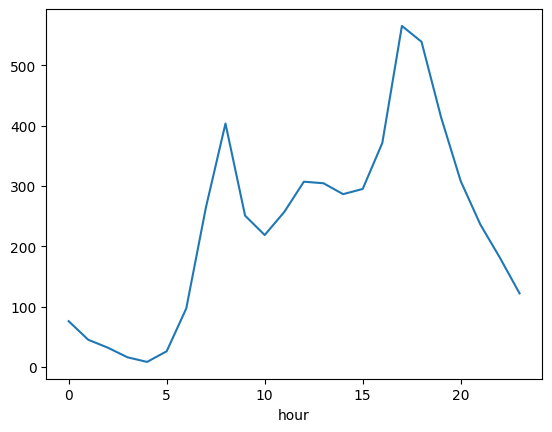

In [161]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
bikes[bikes['season']==3].groupby('hour').total.mean().plot()
display(Markdown(f"""Siguiendo con el análisis del promedio de las bicicletas rentadas pero esta vezpara la estación 3 (verano), se puede ver el comportamiento de la demana sigue siendo el mismo. La
                 gráfica cuenta con los mismos picos y valles, pero que a diferencia de la estación 1, los valores en esta ocasión son mayores al promedio de las 4 estaciones (como se observó inicialmente
                 en el análisis descriptivo). 

                 \n Los valores esta vez incrementaron, teniendo máximos superiores a 500, pero ubicandose en las mismas franjas horarias (alineadas con la entrada y salida de la jornada laboral).
                 Esto muestra que en vernao, las personas sules requerir más el servicio de renta de bicicletas, ya sea por cuestiones estacionales como vacaciones o la propia temperatura."""))

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

Como resultado de la implementación de un modelo de regresión lineal se obtuvo un ***MSE*** de 25931.65, un ***$R^2$*** de 0.2195 y los siguientes coeficientes:

,Coeficiente
Intercepto (season_1),-6.861345
hour,10.539271
season_2,99.249356
season_3,118.613645
season_4,86.347878


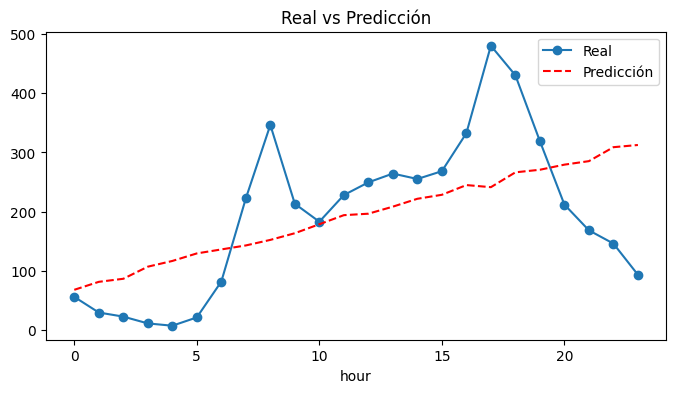

Dado que para realizar el modelo se creo una columna para cada estación, se elimina la columna correspondiente a season_1 dado que se puede saber si el valor corresponde a esta
                 estación mediante las demás columnas creadas, por lo que se puede decir que la season_1 es nuestra base y su coeficiente es el intercepto, teniendo un valor negativo de -6.8. 

                 
 Por otro lado, se ve que el coeficiente de la hora es de +10.5, es decir que conforme la hora avanza, la demanda de bicicletas aumenta en 10 unidades. Adicional, los coeficientes 
                 de las estaciones son positivos, mostrando que la cantidad de bicicletas rentadas aumenta en 99, 118 y 86 unidades con respecto a nuestra base (invierno). 

                 
 Lo anterior muestra un caso que de antemano sabemos que no se cumple dadO que el comportamiento de las bicicletas rentadas por hora y season no se comporta de manera lineal, 
                 presenta picos y valles durante el dia en donde la demanda sube y baja conforme a la hora, por lo que un modelo lineal limita este comportamiento y trata de predecir los valores 
                 siguiendo un crecimiento lineal que no refleja el comportamiento de la información. Lo cual, se confirma mediante las metricas de rendimiento del modelo, teneindo un $R^2$ cercano 
                 al 21% y un error alto.

                 
 También se ve en la gráfica que este modelo presenta grande fallas en todas las horas del día.

In [162]:
# Celda 3

# Se crea una copia del dataframe original que solo contiene las variables a usar
bikes_reg_lin = bikes[['total', 'season', 'hour']].copy()
# Dado que la variable season es categórica, se hace uso de la función get_dummies para generar una columna para cada estación
bikes_reg_lin = pd.get_dummies(bikes_reg_lin, columns=['season'], drop_first=True, dtype=int)

# Se separan las varaibles predictoras en X y las variable de interés en Y
X = bikes_reg_lin.drop('total', axis=1)
Y = bikes['total']

# Se divide el set de datos de manera aleatoria, con 20% para test y 80 para Train
XTrain, XTest, YTrain, YTest = train_test_split(X, Y, test_size=0.2, random_state=0)

modelo = LinearRegression()
modelo.fit(XTrain, YTrain)

YPred = modelo.predict(XTest)
MSE_reg_lin = mean_squared_error(YTest, YPred)
R2_reg_lin = r2_score(YTest, YPred)
df_coef = pd.DataFrame(modelo.coef_, X.columns, columns=['Coeficiente'])
df_intercepto = pd.DataFrame({'Coeficiente': [modelo.intercept_]}, index=['Intercepto (season_1)'])

display(Markdown(f"""Como resultado de la implementación de un modelo de regresión lineal se obtuvo un ***MSE*** de {MSE_reg_lin:.2f}, un ***$R^2$*** de {R2_reg_lin:.4f} y los siguientes coeficientes:"""))
display(pd.concat([df_intercepto, df_coef]))

plt.figure(figsize=(8, 4))
XTest.groupby('hour').apply(lambda x: YTest.loc[x.index].mean()).plot(label='Real', marker='o')
XTest.assign(pred=YPred).groupby('hour')['pred'].mean().plot(label='Predicción', ls='--', color='red')
plt.title('Real vs Predicción')
plt.legend()
plt.show()

display(Markdown(f"""Dado que para realizar el modelo se creo una columna para cada estación, se elimina la columna correspondiente a season_1 dado que se puede saber si el valor corresponde a esta
                 estación mediante las demás columnas creadas, por lo que se puede decir que la season_1 es nuestra base y su coeficiente es el intercepto, teniendo un valor negativo de -6.8. 
                 
                 \n Por otro lado, se ve que el coeficiente de la hora es de +10.5, es decir que conforme la hora avanza, la demanda de bicicletas aumenta en 10 unidades. Adicional, los coeficientes 
                 de las estaciones son positivos, mostrando que la cantidad de bicicletas rentadas aumenta en 99, 118 y 86 unidades con respecto a nuestra base (invierno). 
                 
                 \n Lo anterior muestra un caso que de antemano sabemos que no se cumple dadO que el comportamiento de las bicicletas rentadas por hora y season no se comporta de manera lineal, 
                 presenta picos y valles durante el dia en donde la demanda sube y baja conforme a la hora, por lo que un modelo lineal limita este comportamiento y trata de predecir los valores 
                 siguiendo un crecimiento lineal que no refleja el comportamiento de la información. Lo cual, se confirma mediante las metricas de rendimiento del modelo, teneindo un $R^2$ cercano 
                 al 21% y un error alto.
                 
                 \n También se ve en la gráfica que este modelo presenta grande fallas en todas las horas del día."""))

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [163]:
# Celda 4

# Definición de la función que calcula el mse
def mse(y):
    if y.shape[0] == 0:
        return 0
    else:
        return y.var()
    
# Definición de la función mse para calular la ganancia de una variable predictora j dado el punto de corte k
def mse_impurity(X_col, y, split):
    
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]
    
    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    
    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)
    
    gain = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)
    
    return gain

# Definición de la función best_split para calcular cuál es la mejor variable y punto de cortepara hacer la bifurcación del árbol
def best_split(X, y, num_pct=10):
    features = range(X.shape[1])
    best_split = [0, 0, 0]  # j, split, gain
    
    # Para todas las varibles 
    for j in features:
        
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]
        
        # Para cada partición
        for split in splits:
            gain = mse_impurity(X.iloc[:, j], y, split)
                        
            if gain > best_split[2]:
                best_split = [j, split, gain]
    
    return best_split

# Definición de la función tree_grow para hacer un crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    
    # Si solo es una observación
    if X.shape[0] == 1:
        return dict(y_pred=y.iloc[:1].values[0], y_prob=0.5, level=level, split=-1, n_samples=1, gain=0)
    
    # Calcular la mejor división
    j, split, gain = best_split(X, y, num_pct)
    
    # Guardar el árbol y estimar la predicción
    y_pred = y.mean() 
    
    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)
    # Revisar el criterio de parada 
    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree   
    
    # Continuar creando la partición
    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    # Siguiente iteración para cada partición
    
    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    
    return tree

# Definición de la función tree_predict para hacer predicciones según las variables 'X' y el árbol 'tree'
def tree_predict(X, tree):
    predicted = np.ones(X.shape[0])

    # Revisar si es el nodo final
    if tree['split'] == -1:
        predicted = predicted * tree['y_pred']
    else:
        
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:  # Si el nodo izquierdo está vacio solo continua con el derecho 
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])
        elif X_r.shape[0] == 0:  #  Si el nodo derecho está vacio solo continua con el izquierdo
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'])
            predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted

def grafica_arbol(nodo, ruta=""):
    if nodo.get('level') == 3:
        print(f"Predicción: {nodo['y_pred']:.2f} | Condiciones: {ruta}")
    else:
        col, valor = nodo['split']
        var = "Hora" if col == 0 else f"Season_{col}"
        
        grafica_arbol(nodo['sl'], ruta + f" {var} < {valor} |")
        grafica_arbol(nodo['sr'], ruta + f" {var} >= {valor} |")

In [164]:
display(Markdown(f"""Para la creación del arbol de decisión manual, se crearon varias funciones basadas en las explicadas para el ejemplo de clasificación, pero modificandolas para poder ser usadas en
                 un problema de regresión. Los cambios principles se hicieron en la métrica usada para poder definir que una partición generaba ganancia, cambiando de indice Gini a buscar la reducción 
                 de la varianza (MSE).
                 
                 \n La implementacióm siguió la misma logica, en donde se evalua cada set de datos de la partición generada (izquierda y derecha) para poder definir la estructura del arbol. Adicionalmente,
                 se usó una partición de 10 para las variables y para la profundidad del arbol se usó una profundida maxima de 3, teniendo así 8 nodos resultantes."""))

# Se crea una copia del dataframe original que solo contiene las variables a usar
bikes_arbol = bikes[['total', 'season', 'hour']].copy()
# Dado que la variable season es categórica, se hace uso de la función get_dummies para generar una columna para cada estación
bikes_arbol = pd.get_dummies(bikes_arbol, columns=['season'], dtype=int)

# Se separan las varaibles predictoras en X y las variable de interés en Y
X_arbol = bikes_arbol.drop('total', axis=1)
Y_arbol = bikes_arbol['total']

# Aplicación de la función tree_grow
tree = tree_grow(X_arbol, Y_arbol, level=0, min_gain=0.001, max_depth=3, num_pct=10)
grafica_arbol(tree)

display(Markdown(f"""Finalmente se puede ver que el arbol genero los 8 valores finales esperados, en donde se pueden ver las condiciones que se tienen que cumplir para poder tener cierto valor de 
                 bicicletas erntadas dependiendo de la hora y la season."""))

Para la creación del arbol de decisión manual, se crearon varias funciones basadas en las explicadas para el ejemplo de clasificación, pero modificandolas para poder ser usadas en
                 un problema de regresión. Los cambios principles se hicieron en la métrica usada para poder definir que una partición generaba ganancia, cambiando de indice Gini a buscar la reducción 
                 de la varianza (MSE).

                 
 La implementacióm siguió la misma logica, en donde se evalua cada set de datos de la partición generada (izquierda y derecha) para poder definir la estructura del arbol. Adicionalmente,
                 se usó una partición de 10 para las variables y para la profundidad del arbol se usó una profundida maxima de 3, teniendo así 8 nodos resultantes.

Predicción: 25.18 | Condiciones:  Hora < 8.0 | Hora < 7.0 | Hora < 6.0 |
Predicción: 76.26 | Condiciones:  Hora < 8.0 | Hora < 7.0 | Hora >= 6.0 |
Predicción: 242.42 | Condiciones:  Hora < 8.0 | Hora >= 7.0 | Season_1 < 1.0 |
Predicción: 124.43 | Condiciones:  Hora < 8.0 | Hora >= 7.0 | Season_1 >= 1.0 |
Predicción: 325.04 | Condiciones:  Hora >= 8.0 | Hora < 21.0 | Season_1 < 1.0 |
Predicción: 176.13 | Condiciones:  Hora >= 8.0 | Hora < 21.0 | Season_1 >= 1.0 |
Predicción: 152.48 | Condiciones:  Hora >= 8.0 | Hora >= 21.0 | Season_1 < 1.0 |
Predicción: 71.18 | Condiciones:  Hora >= 8.0 | Hora >= 21.0 | Season_1 >= 1.0 |


Finalmente se puede ver que el arbol genero los 8 valores finales esperados, en donde se pueden ver las condiciones que se tienen que cumplir para poder tener cierto valor de 
                 bicicletas erntadas dependiendo de la hora y la season.

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

Mejor combinación encontrada: {'max_depth': 9, 'min_samples_leaf': 1}


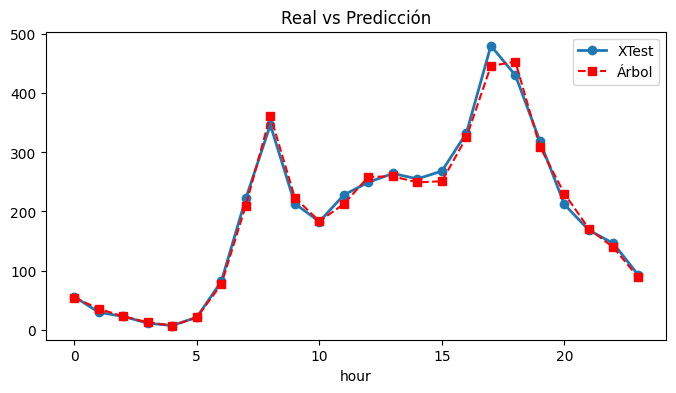

Se hace la implementación de un arbol de decisión pero esta vez usando la libreria scikit-learn, en donde se buscó hacer la configuración de dos parámetros del arbol; max_depth 
                 y min_samples_leaf, obteniendo el mejor valor para el caso dependiendo del valor de mse obtenido para cada combinación, asegurandonos de usar los parámetros que garanticen el menor valor
                 de este.

                 
 Para este modelo, se obtuvo un ***MSE de 13373.3846*** y un ***$R^2$ de 0.5975***.

                 
 Adicional, se puede ver que los resultados de la predicción se ajustan al comportamiento real de los datos, teniendo que siguen la dinamica horaria establecida.

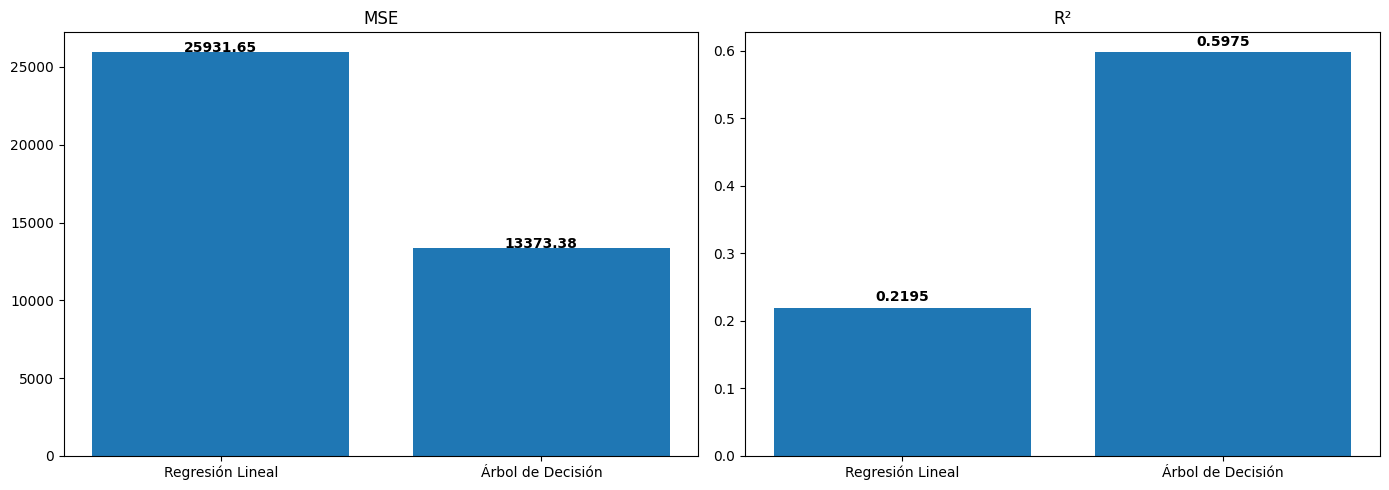

Finalmente, se puede comparar el resultado obtenido por ambos modelos implementados (regresión lineal y árbol de decisión), pudiendo ver que el árbol presenta mejor desempeño general
                 bajo las dos métricas usadas, teniendo un mse menor y un R² mayor. Por lo que se puede concluir que este modelo representa mejor las relaciones y dinamicas existentes en los datos, 
                 generando una predicción más precisa que la regresión lineal. 

In [165]:
# Celda 5
param_grid = {'max_depth': [8,9,10], 'min_samples_leaf': [1,2,3]}
grid_search = GridSearchCV(estimator=DecisionTreeRegressor(random_state=1), param_grid=param_grid, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(XTrain, YTrain)
best_tree = grid_search.best_estimator_
print(f"Mejor combinación encontrada: {grid_search.best_params_}")

y_pred_final = best_tree.predict(XTest)
mse_tree = mean_squared_error(YTest, y_pred_final)
r2_tree = r2_score(YTest, y_pred_final)

plt.figure(figsize=(8, 4))
XTest.assign(real=YTest).groupby('hour')['real'].mean().plot(label='XTest', marker='o', linewidth=2)
XTest.assign(pred=y_pred_final).groupby('hour')['pred'].mean().plot(label='Árbol', ls='--', color='red', marker='s')
plt.title('Real vs Predicción')
plt.legend()
plt.show()

display(Markdown(f"""Se hace la implementación de un arbol de decisión pero esta vez usando la libreria scikit-learn, en donde se buscó hacer la configuración de dos parámetros del arbol; max_depth 
                 y min_samples_leaf, obteniendo el mejor valor para el caso dependiendo del valor de mse obtenido para cada combinación, asegurandonos de usar los parámetros que garanticen el menor valor
                 de este.
                 
                 \n Para este modelo, se obtuvo un ***MSE de {mse_tree:.4f}*** y un ***$R^2$ de {r2_tree:.4f}***.
                 
                 \n Adicional, se puede ver que los resultados de la predicción se ajustan al comportamiento real de los datos, teniendo que siguen la dinamica horaria establecida."""))

modelos = ['Regresión Lineal', 'Árbol de Decisión']
mse_values = [MSE_reg_lin, mse_tree]  
r2_values = [R2_reg_lin, r2_tree] 

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].bar(modelos, mse_values)
ax[0].set_title('MSE')
for i, v in enumerate(mse_values):
    ax[0].text(i, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold')

ax[1].bar(modelos, r2_values)
ax[1].set_title('R²')
for i, v in enumerate(r2_values):
    ax[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

display(Markdown(f"""Finalmente, se puede comparar el resultado obtenido por ambos modelos implementados (regresión lineal y árbol de decisión), pudiendo ver que el árbol presenta mejor desempeño general
                 bajo las dos métricas usadas, teniendo un mse menor y un R² mayor. Por lo que se puede concluir que este modelo representa mejor las relaciones y dinamicas existentes en los datos, 
                 generando una predicción más precisa que la regresión lineal. """))

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [166]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [167]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [168]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [169]:
#Se crea una función que permite calcular y graficar las principales metricas para poder análizar el poder de predicción de un modelo de clasificación
#Variables para guardar los resultdos de los MSE para cada modelo probado
ejeX = []
ejeY = []
modelo = ''

def calcular_y_graficar(XTrain,yTrain,XTest,yTest,prediccion,prediccionprob,model): 

    if model == 'RegLog':
        modelo = 'Regresión Logística'
    elif model == 'Arbol':
        modelo = 'Árbol de Decisión'

    #Se calcula la matriz de confusion
    matriz_c = confusion_matrix(y_true=yTest, y_pred=prediccion)

    #Se calcula el accuracy de la prediccion
    accuracy=accuracy_score(y_true=yTest, y_pred=prediccion)

    #Se calcula la precisión de la prediccion
    precision=precision_score(y_true=yTest, y_pred=prediccion)

    #Se calcula el F1-Score
    f1 = f1_score(y_test, prediccion)

    #Se calcula la curva ROC, además del area bajo la curva (AUC)
    fpr, tpr, thresholds = metrics.roc_curve(yTest, prediccionprob[:,1], pos_label=1)
    AUC=metrics.auc(fpr, tpr)

    #Se calcula el error de predicción del modelo
    error = np.mean(y_test != prediccion)

    fig, ax = plt.subplots(1, 3, figsize=(20, 5))

    ax[0].axis('off')
    rect = plt.Rectangle((0, 0), 1, 1, fill=False, color="black", lw=2)
    ax[0].add_patch(rect)
    ax[0].text(0.5, 0.8, f"EVALUACIÓN DE \n {modelo}", fontsize=16, fontweight='bold', ha='center')
    ax[0].text(0.1, 0.70, f"● Precisión: {precision:.4f}", fontsize=14, ha='left')
    ax[0].text(0.1, 0.60, f"● Accuracy: {accuracy:.4f}", fontsize=14, ha='left')
    ax[0].text(0.1, 0.50, f"● F1-Score: {f1:.4f}", fontsize=14, ha='left')
    ax[0].text(0.1, 0.40, f"● Error: {error:.4f}", fontsize=14, ha='left') 
    ax[0].text(0.5, 0.25, f"Matriz de Confusión:\n{matriz_c}", fontsize=14, ha='center', va='center', family='monospace', bbox=dict(facecolor='lightgray', alpha=0.3))
    
    ax[1].plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % AUC)
    ax[1].set_title('Receiver Operating Characteristic (ROC)')
    ax[1].legend(loc = 'lower right')
    ax[1].plot([0, 1], [0, 1],'r--')
    ax[1].set_xlim([-0.01, 1])
    ax[1].set_ylim([0, 1.05])
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_xlabel('False Positive Rate')

    ejeX.extend([f'Accuracy-{model}', f'F1-Score-{model}', f'Precision-{model}',f'AUC-{model}',f'Error-{model}'])
    ejeY.extend([accuracy,f1,precision,AUC,error])

    posiciones = [posicion for posicion, etiqueta in enumerate(ejeX) if model in etiqueta]
    etiqueta = [etiqueta for etiqueta in ejeX if model in etiqueta]

    ejeX_local = etiqueta
    ejeY_local = [ejeY[i] for i in posiciones]

    ax[2].bar(ejeX_local,ejeY_local)
    ax[2].set_title("Comparación de métricas")
    ax[2].set_ylim([0, max(accuracy,precision,AUC)+0.1])
    ax[2].tick_params(axis='x', rotation=45)

    def addlabels(x,y,plotP):
        for i in range(len(x)):
            plotP.text(i,y[i],f'{y[i]:.4f}')
    addlabels(ejeX_local,ejeY_local,ax[2])
    
    plt.tight_layout()
    plt.show()

#### Árbol de Decisión

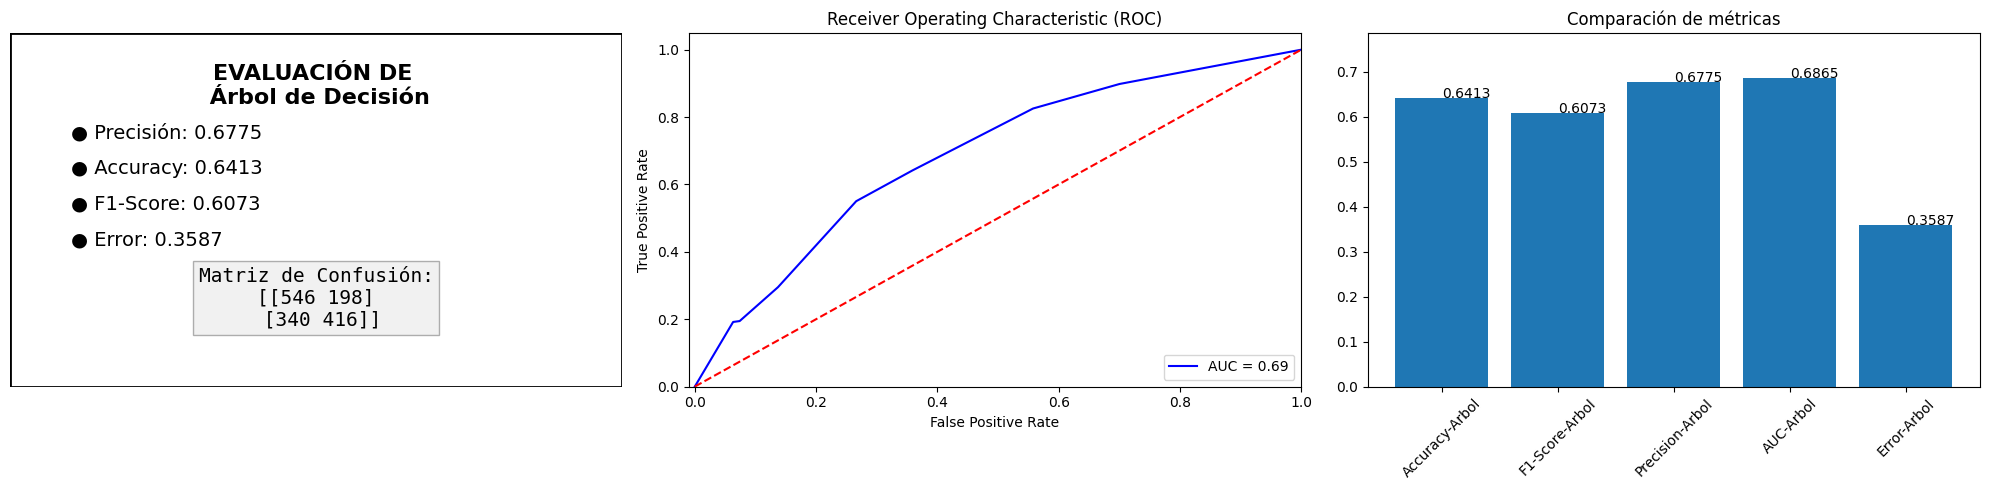

#### Regresión Logística

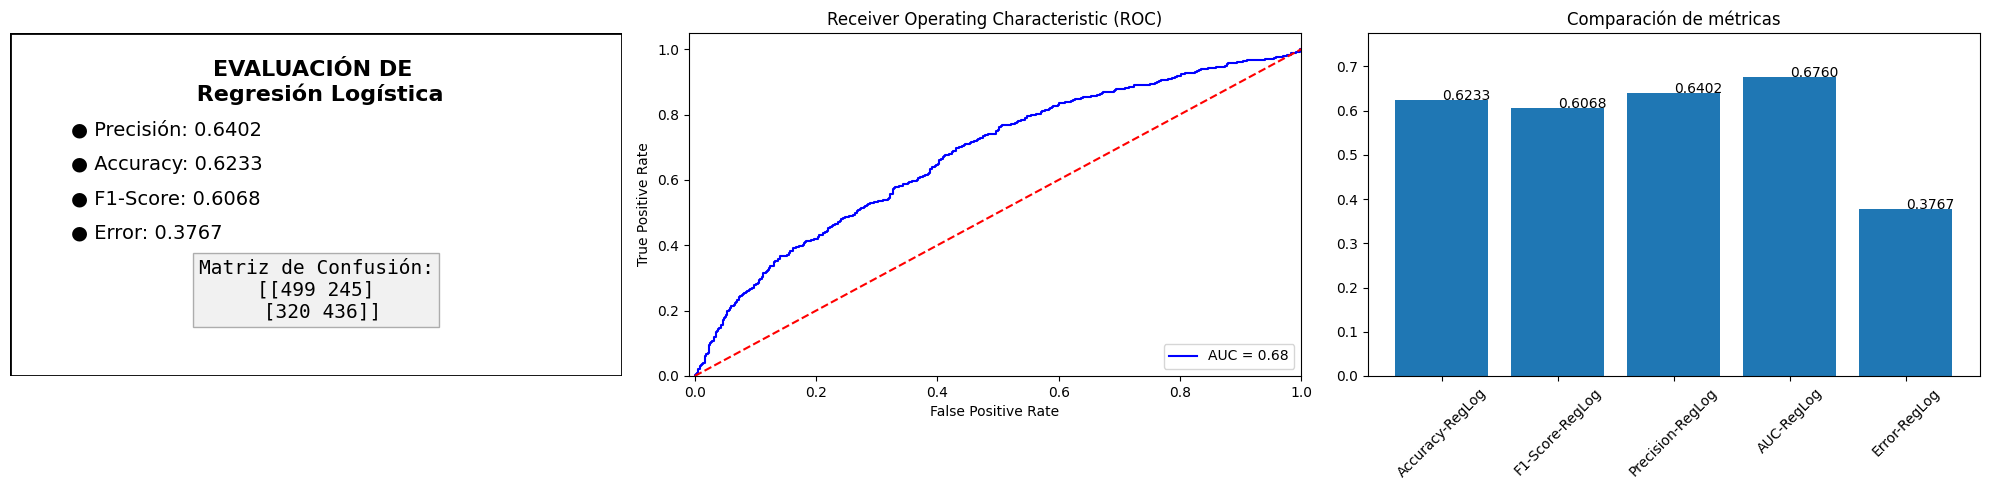

Al Observar los valores obtenidos por ambos modelos, se puede decir que el ganador es el árbol de decisión aunque los valores fueron cercanos. Analizando principalmente lo obtenido
                 para Accuracy, vemos que el árbol tiene un valor de 0.6413, mientras que la regresión tiene un valor de 0.6233. Por otro lado, si vemos el F1-Score, vemos que son muy similares; 0.6073
                 para el árbol y 0.6068 para la regresión, teniendo una diferencia de apenas 0.0005. 

                 
 Por tro lado, podemos ver meticas adicionales que soportan lo dicho anteriormente, como lo es el caso del AUC, el cual tambipn es mayor en el modelo de árbol.

In [170]:
# Celda 6

#Calibación de un modelo de árbol de Decisión
def class_tree(XTrain,yTrain,XTest,yTest):
    model = 'Arbol' 
    param_grid = {'max_depth': [3, 5, 10, None], 'min_samples_leaf': [1, 5, 10, 20]}
    grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=0), param_grid=param_grid, cv=10, scoring='roc_auc', n_jobs=-1)
    grid_search.fit(XTrain, yTrain)
    best_clf_tree = grid_search.best_estimator_
    prediccionesTree = best_clf_tree.predict(XTest)
    prediccionesProbTree = best_clf_tree.predict_proba(XTest)
    display(Markdown(f"""#### Árbol de Decisión"""))
    calcular_y_graficar(XTrain,yTrain,XTest,yTest,prediccionesTree,prediccionesProbTree,model)

#Calibación de un modelo de Regresión Logística
def class_reglog(XTrain,yTrain,XTest,yTest):
    model = 'RegLog' 
    clfRegLog= LogisticRegression(random_state=0,max_iter=10000)
    clfRegLog.fit(XTrain,yTrain)
    prediccionesRegLog=clfRegLog.predict(XTest)
    prediccionesProbRegLog=clfRegLog.predict_proba(XTest)
    display(Markdown(f"""#### Regresión Logística"""))
    calcular_y_graficar(XTrain,yTrain,XTest,yTest,prediccionesRegLog,prediccionesProbRegLog,model)

class_tree(X_train,y_train,X_test,y_test)
class_reglog(X_train,y_train,X_test,y_test)

display(Markdown(f"""Al Observar los valores obtenidos por ambos modelos, se puede decir que el ganador es el árbol de decisión aunque los valores fueron cercanos. Analizando principalmente lo obtenido
                 para Accuracy, vemos que el árbol tiene un valor de 0.6413, mientras que la regresión tiene un valor de 0.6233. Por otro lado, si vemos el F1-Score, vemos que son muy similares; 0.6073
                 para el árbol y 0.6068 para la regresión, teniendo una diferencia de apenas 0.0005. 
                 
                 \n Por tro lado, podemos ver meticas adicionales que soportan lo dicho anteriormente, como lo es el caso del AUC, el cual tambipn es mayor en el modelo de árbol."""))

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [171]:
# Creación de 300 muestras de bootstrap
n_estimators = 300
np.random.seed(3)
n_samples = X_train.shape[0]
samples_oob = []

samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_estimators)]
seeds = np.random.randint(1, 10000, size=n_estimators)

modelos = {}
y_pred = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators)))
errors = np.zeros(n_estimators)

# Se calibran 100 arboles de decisión en donde se seleccionó como único parámetro de configuración un max_depth de 5
for i in range(0, 100):
    modelos[i] = DecisionTreeClassifier(max_depth=5, random_state=seeds[i])
    modelos[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred.iloc[:, i] = modelos[i].predict(X_test)
    samples_oob.append(sorted(set(range(n_samples)) - set(samples[i])))
    y_pred_ponderada = modelos[i].predict(X_train.iloc[samples_oob[i]])
    errors[i] = 1 - metrics.accuracy_score(y_train.iloc[samples_oob[i]], y_pred_ponderada)

# Se calibran 100 arboles de decisión en donde se seleccionó como único parámetro de configuración un min_samples_leaf de 10
for i in range(100, 200):
    modelos[i] = DecisionTreeClassifier(min_samples_leaf=10, random_state=seeds[i])
    modelos[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred.iloc[:, i] = modelos[i].predict(X_test)
    samples_oob.append(sorted(set(range(n_samples)) - set(samples[i])))
    y_pred_ponderada = modelos[i].predict(X_train.iloc[samples_oob[i]])
    errors[i] = 1 - metrics.accuracy_score(y_train.iloc[samples_oob[i]], y_pred_ponderada)

# Se calibran 100 modelos con una regresión logística
for i in range(200, 300):
    modelos[i] = LogisticRegression(random_state=seeds[i])
    modelos[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred.iloc[:, i] = modelos[i].predict(X_test)
    samples_oob.append(sorted(set(range(n_samples)) - set(samples[i])))
    y_pred_ponderada = modelos[i].predict(X_train.iloc[samples_oob[i]])
    errors[i] = 1 - metrics.accuracy_score(y_train.iloc[samples_oob[i]], y_pred_ponderada)

In [172]:
# Celda 7

# Votación mayoritaria
y_pred_mayoritaria = (y_pred.sum(axis=1) >= (n_estimators / 2)).astype(np.int64)

# Se evalua el desempeño de cada modelo de manera independiente
# Árboles de Decisión con max_depth de 5
y_pred_b1 = (y_pred.iloc[:, 0:100].sum(axis=1) >= 50).astype(int)
acc_b1 = accuracy_score(y_test, y_pred_b1)
f1_b1 = f1_score(y_test, y_pred_b1)

# Árboles de Decisión con min_samples_leaf de 10
y_pred_b2 = (y_pred.iloc[:, 100:200].sum(axis=1) >= 50).astype(int)
acc_b2 = accuracy_score(y_test, y_pred_b2)
f1_b2 = f1_score(y_test, y_pred_b2)

# Regresiones Logísticas
y_pred_b3 = (y_pred.iloc[:, 200:300].sum(axis=1) >= 50).astype(int)
acc_b3 = accuracy_score(y_test, y_pred_b3)
f1_b3 = f1_score(y_test, y_pred_b3)

# Se evalua el resultado del ensamble total
acc_total = accuracy_score(y_test, y_pred_mayoritaria)
f1_total = f1_score(y_test, y_pred_mayoritaria)

data_mayoritaria = {
    'Modelo ': [
        'Árboles - Max Depth', 
        'Árboles - Min Samples Leaf', 
        'Regresión Logística', 
        'Ensambe Total'
    ],
    'Accuracy': [acc_b1, acc_b2, acc_b3, acc_total],
    'F1-Score': [f1_b1, f1_b2, f1_b3, f1_total]
}
df_resultados_mayoritaria = pd.DataFrame(data_mayoritaria)
df_resultados_mayoritaria = df_resultados_mayoritaria.round(4)

display(Markdown(f"""Resultados - Ensamble por votación mayoritaria"""))
display(df_resultados_mayoritaria)

display(Markdown(f"""Se puede observar que el desempeño general del ensamble realizado tiene valores de accuracy y f1-score menores a algunos modelos, puntualmente se ve que el ensamble mejora con 
                 respecto a los modelos de regresión logística, pero que su desempeño es menor a los valores de los arboles de decisión. 
                 
                 \n Este comportamiento se debe a que los modelos de regresión tienen un desempeño 'bajo' comparado con los arboles, por lo cual hace que el resultado final del ensamble baje,
                 lo cual no significa que el modelo resultante sea malo, sino que por le contrario, gracias a la diversidad ofrecida por el ensamble de todos los modelos, este es más robusto y puede
                 operar mejor prediciendo nuevos valores que sean diferentes a los usados en el entrenamiento."""))

Resultados - Ensamble por votación mayoritaria

,Modelo,Accuracy,F1-Score
0,Árboles - Max Depth,0.6547,0.6505
1,Árboles - Min Samples Leaf,0.6520,0.6482
2,Regresión Logística,0.6187,0.6146
3,Ensambe Total,0.6207,0.6158


Se puede observar que el desempeño general del ensamble realizado tiene valores de accuracy y f1-score menores a algunos modelos, puntualmente se ve que el ensamble mejora con 
                 respecto a los modelos de regresión logística, pero que su desempeño es menor a los valores de los arboles de decisión. 

                 
 Este comportamiento se debe a que los modelos de regresión tienen un desempeño 'bajo' comparado con los arboles, por lo cual hace que el resultado final del ensamble baje,
                 lo cual no significa que el modelo resultante sea malo, sino que por le contrario, gracias a la diversidad ofrecida por el ensamble de todos los modelos, este es más robusto y puede
                 operar mejor prediciendo nuevos valores que sean diferentes a los usados en el entrenamiento.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [173]:
# Celda 8

# Votación Ponderada
# Se evalua el desempeño de cada modelo de manera independiente
# Árboles de Decisión con max_depth de 5
alpha1 = (1 - errors[0:100]) / (1 - errors[0:100]).sum()
weighted_sum_1 = ((y_pred.iloc[:, 0:100]) * alpha1).sum(axis=1)
y_pred_1 = (weighted_sum_1 >= 0.5).astype(np.int64)
acc_1_ponderado = accuracy_score(y_test, y_pred_1)
f1_1_ponderado = f1_score(y_test, y_pred_1)

# Árboles de Decisión con min_samples_leaf de 10
alpha2 = (1 - errors[100:200]) / (1 - errors[100:200]).sum()
weighted_sum_2 = ((y_pred.iloc[:, 100:200]) * alpha2).sum(axis=1)
y_pred_2 = (weighted_sum_2 >= 0.5).astype(np.int64)
acc_2_ponderado = accuracy_score(y_test, y_pred_2)
f1_2_ponderado = f1_score(y_test, y_pred_2)

# Regresiones Logísticas
alpha3 = (1 - errors[200:300]) / (1 - errors[200:300]).sum()
weighted_sum_3 = ((y_pred.iloc[:, 200:300]) * alpha3).sum(axis=1)
y_pred_3 = (weighted_sum_3 >= 0.5).astype(np.int64)
acc_3_ponderado = accuracy_score(y_test, y_pred_3)
f1_3_ponderado = f1_score(y_test, y_pred_3)

# Se evalua el resultado del ensamble total
alpha_total = (1 - errors) / (1 - errors).sum()
weighted_sum_total = ((y_pred) * alpha_total).sum(axis=1)
y_pred_total = (weighted_sum_total >= 0.5).astype(np.int64)
acc_total_ponderado = accuracy_score(y_test, y_pred_total)
f1_total_ponderado = f1_score(y_test, y_pred_total)

data_ponderada = {
    'Modelo ': [
        'Árboles - Max Depth', 
        'Árboles - Min Samples Leaf', 
        'Regresión Logística', 
        'Ensambe Total'
    ],
    'Accuracy': [acc_1_ponderado , acc_2_ponderado , acc_3_ponderado , acc_total_ponderado],
    'F1-Score': [f1_1_ponderado, f1_2_ponderado, f1_3_ponderado, f1_total_ponderado]
}
df_resultados_ponderada = pd.DataFrame(data_ponderada)
df_resultados_ponderada = df_resultados_ponderada.round(4)

display(Markdown(f"""Resultados - Ensamble por votación ponderada"""))
display(df_resultados_ponderada)

display(Markdown(f"""Se puede observar que, al igual que con la votación mayoritaría, el desempeño general del ensamble realizado tiene valores de accuracy y f1-score menores a algunos modelos, 
                 evidenciando que crear el ensamble representa una mejora con respecto a los modelos de regresión logística, pero que su desempeño es menor a los valores de los arboles de decisión. 
                 
                 \n Lo anterior muestra que los valores de regresión logística están provocando que el resultado del ensamble baje y aunque se use votación ponderada, en donde el peso asigando a 
                 los modelos provoque que estos no tengan tanta relevancia como los modelos basados en arboles, sus valores siguen bajando el desempeño general. Adicionamente, la diferencia de 
                 rendimiento entre los arboles y las regresiones no es muy alto, por lo que los alphas asignados no penalizan tan fuertemenete a los valores de regresión."""))

Resultados - Ensamble por votación ponderada

,Modelo,Accuracy,F1-Score
0,Árboles - Max Depth,0.6540,0.6491
1,Árboles - Min Samples Leaf,0.6520,0.6459
2,Regresión Logística,0.6193,0.6150
3,Ensambe Total,0.6200,0.6143


Se puede observar que, al igual que con la votación mayoritaría, el desempeño general del ensamble realizado tiene valores de accuracy y f1-score menores a algunos modelos, 
                 evidenciando que crear el ensamble representa una mejora con respecto a los modelos de regresión logística, pero que su desempeño es menor a los valores de los arboles de decisión. 

                 
 Lo anterior muestra que los valores de regresión logística están provocando que el resultado del ensamble baje y aunque se use votación ponderada, en donde el peso asigando a 
                 los modelos provoque que estos no tengan tanta relevancia como los modelos basados en arboles, sus valores siguen bajando el desempeño general. Adicionamente, la diferencia de 
                 rendimiento entre los arboles y las regresiones no es muy alto, por lo que los alphas asignados no penalizan tan fuertemenete a los valores de regresión.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

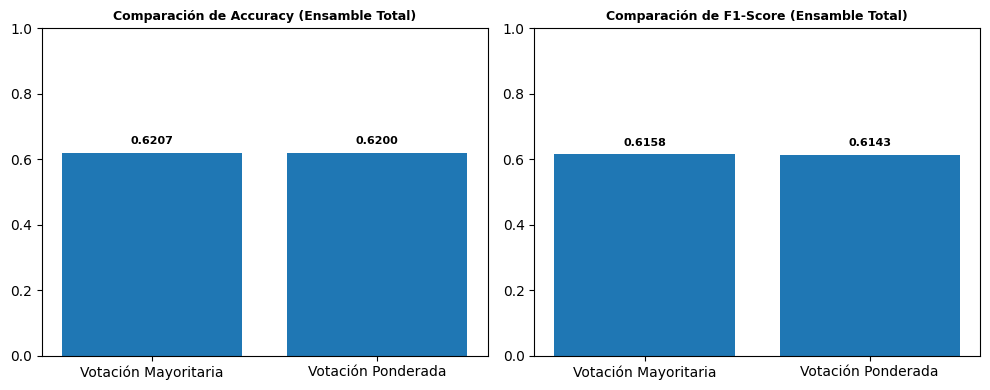

Después de haber creado los dos ensambles; votación mayoritaria y poderada, se puede ver que el ensamble por votación mayoritaria presenta mejores metricas
                 con un accuracy de 0.6207 y un F1-Score de 0.6158. Las cuales son muy similares a las obtenidas en votación ponderada.

                 
 La votación ponderada presenta ventajas al asignar pesos a cada modelo dependiendo de su desempeño, teniendo así un modelo más estable que esta blindado ante posibles cambios en 
                 las predicciones que repesenten grandes brechas. Adicional, la votación mayoritaria es buena per asume que todos los modelos tienen el mismo peso, por lo que si se tienen casos en 
                 donde las predicciones cambien mucho, este modelo tendría más varianza.

                 
 Por otro lado, la votación ponderada presenta una complejidad mayor, por lo que si los resultados de los modelos indiviuales no presentan mayor diferencia, resulta óptimo usar
                 una votación mayoritaria, la cual dará un resultado similar pero sin incurrir es costos computacionales adicionales.

                 
 Adicionalmente, se puede ver que los resultados obtenidos están limitados por el desempeño de los modelos individuales, por lo que si quiere mejorar el resultado, se deben mejorar
                 los parámetros usados en los arboles y calibrar mejor todos los modelos en general. 

                 
 Finalmente, se concluye que ambos ensambles tienen un poder predictivo muy similar, pero que el ensamble por votación mayoritaria es ligeramente superior, al mostrar mejores metricas
                 y tener un costo computacional menor. 
                  

In [174]:
# Celda 9
metodos = ['Votación Mayoritaria', 'Votación Ponderada']
accuracy_values = [df_resultados_mayoritaria.iloc[3, 1], df_resultados_ponderada.iloc[3, 1]]
f1_values = [df_resultados_mayoritaria.iloc[3, 2], df_resultados_ponderada.iloc[3, 2]]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

bars1 = ax[0].bar(metodos, accuracy_values)
ax[0].set_title('Comparación de Accuracy (Ensamble Total)', fontsize=9, fontweight='bold')
ax[0].set_ylim(0, 1.0)

for bar in bars1:
    yval = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=8)

bars2 = ax[1].bar(metodos, f1_values)
ax[1].set_title('Comparación de F1-Score (Ensamble Total)', fontsize=9, fontweight='bold')
ax[1].set_ylim(0, 1.0)

# Etiquetas de datos para F1-Score
for bar in bars2:
    yval = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=8)

# Ajuste final
plt.tight_layout()
plt.show()

display(Markdown(f"""Después de haber creado los dos ensambles; votación mayoritaria y poderada, se puede ver que el ensamble por votación mayoritaria presenta mejores metricas
                 con un accuracy de 0.6207 y un F1-Score de 0.6158. Las cuales son muy similares a las obtenidas en votación ponderada.
                 
                 \n La votación ponderada presenta ventajas al asignar pesos a cada modelo dependiendo de su desempeño, teniendo así un modelo más estable que esta blindado ante posibles cambios en 
                 las predicciones que repesenten grandes brechas. Adicional, la votación mayoritaria es buena per asume que todos los modelos tienen el mismo peso, por lo que si se tienen casos en 
                 donde las predicciones cambien mucho, este modelo tendría más varianza.
                 
                 \n Por otro lado, la votación ponderada presenta una complejidad mayor, por lo que si los resultados de los modelos indiviuales no presentan mayor diferencia, resulta óptimo usar
                 una votación mayoritaria, la cual dará un resultado similar pero sin incurrir es costos computacionales adicionales.

                 \n Adicionalmente, se puede ver que los resultados obtenidos están limitados por el desempeño de los modelos individuales, por lo que si quiere mejorar el resultado, se deben mejorar
                 los parámetros usados en los arboles y calibrar mejor todos los modelos en general. 

                 \n Finalmente, se concluye que ambos ensambles tienen un poder predictivo muy similar, pero que el ensamble por votación mayoritaria es ligeramente superior, al mostrar mejores metricas
                 y tener un costo computacional menor. 
                  """))